In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries are ready!")


Libraries are ready!


In [3]:
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)



Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


matches.head()
deliveries.head()
matches.info()
matches.isnull().sum()

In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [7]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [8]:
# Fix team names (old franchises renamed over years)
team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches['team1'] = matches['team1'].replace(team_rename)
matches['team2'] = matches['team2'].replace(team_rename)
matches['winner'] = matches['winner'].replace(team_rename)
deliveries['batting_team'] = deliveries['batting_team'].replace(team_rename)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_rename)

print("Cleaning done!")

Cleaning done!


In [11]:
matches['id'] = matches['id'].astype(str)
deliveries['match_id'] = deliveries['match_id'].astype(str)
match_meta = matches.set_index('id')[['season', 'venue']]
deliveries['season'] = deliveries['match_id'].map(match_meta['season'])
deliveries['venue'] = deliveries['match_id'].map(match_meta['venue'])

In [12]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,season,venue
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,2007/08,M Chinnaswamy Stadium
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,2007/08,M Chinnaswamy Stadium
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,2007/08,M Chinnaswamy Stadium
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,2007/08,M Chinnaswamy Stadium
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,2007/08,M Chinnaswamy Stadium


In [14]:
#Detect batter column name
batter_col = 'batter' if 'batter' in deliveries.columns else 'batsman'
print('Cleaning done! Batter column:', batter_col)


Cleaning done! Batter column: batter


In [16]:
import warnings
warnings.filterwarnings('ignore')

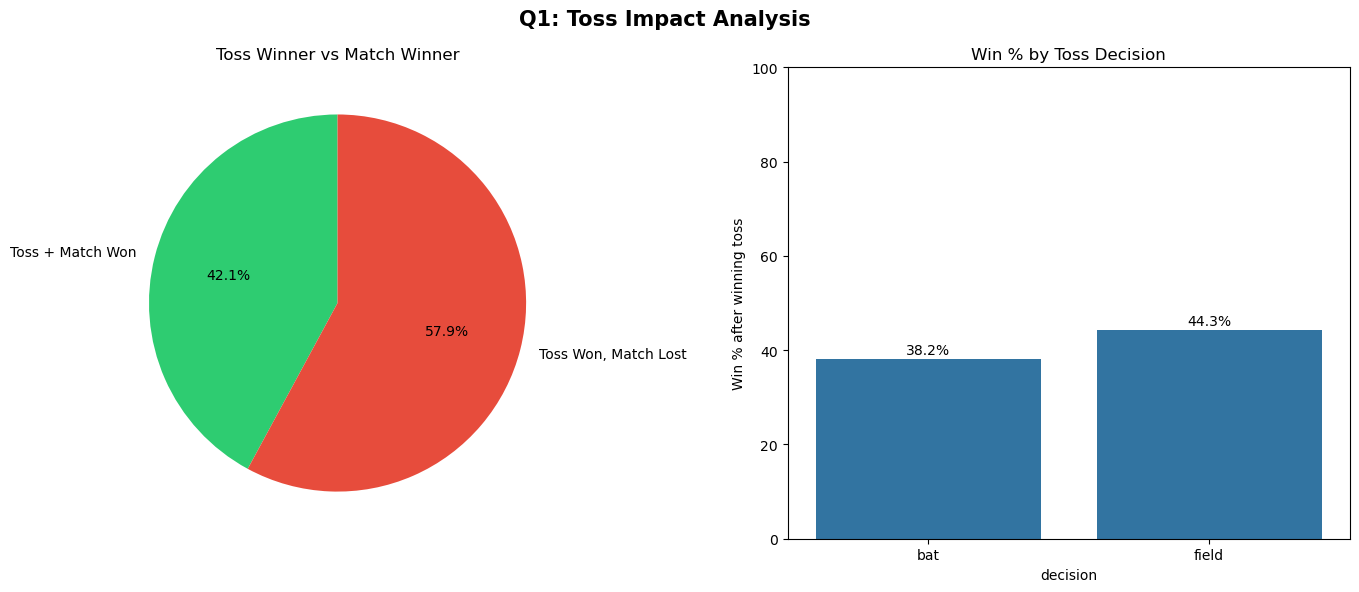

📌 Toss winners win only 42.1% of matches — barely better than a coin flip!


In [17]:
#Does winning the toss win the match?
valid = matches[matches['winner'].notna()].copy()
toss_win = (valid['toss_winner'] == valid['winner']).sum()
pct = round(toss_win / len(valid) * 100, 1)

# By toss decision
decision_win = valid.groupby('toss_decision').apply(
    lambda x: (x['toss_winner'] == x['winner']).mean() * 100
).reset_index()
decision_win.columns = ['decision', 'win_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie([pct, 100-pct],
            labels=['Toss + Match Won', 'Toss Won, Match Lost'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Toss Winner vs Match Winner')

sns.barplot(data=decision_win, x='decision', y='win_pct', ax=axes[1])
axes[1].set_title('Win % by Toss Decision')
axes[1].set_ylabel('Win % after winning toss')
axes[1].set_ylim(0, 100)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()+1), ha='center')

plt.suptitle('Q1: Toss Impact Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'📌 Toss winners win only {pct}% of matches — barely better than a coin flip!')

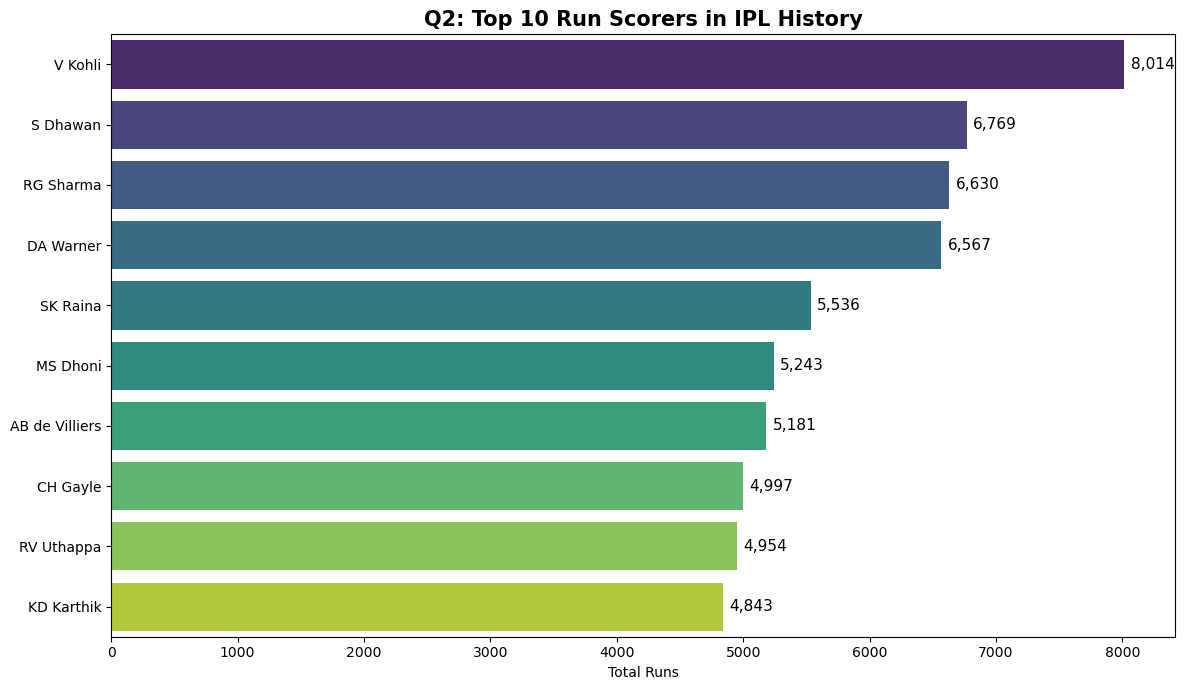

📌 V Kohli leads with 8,014 runs!


In [18]:
#Top 10 run scorers of all time
top_bat = (deliveries.groupby(batter_col)['batsman_runs']
           .sum().sort_values(ascending=False).head(10).reset_index())
top_bat.columns = ['batter', 'runs']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_bat, x='runs', y='batter', palette='viridis')
for i, val in enumerate(top_bat['runs']):
    plt.text(val+50, i, f'{val:,}', va='center', fontsize=11)
plt.title('Q2: Top 10 Run Scorers in IPL History', fontsize=15, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.show()
print(f'📌 {top_bat.iloc[0]["batter"]} leads with {top_bat.iloc[0]["runs"]:,} runs!')


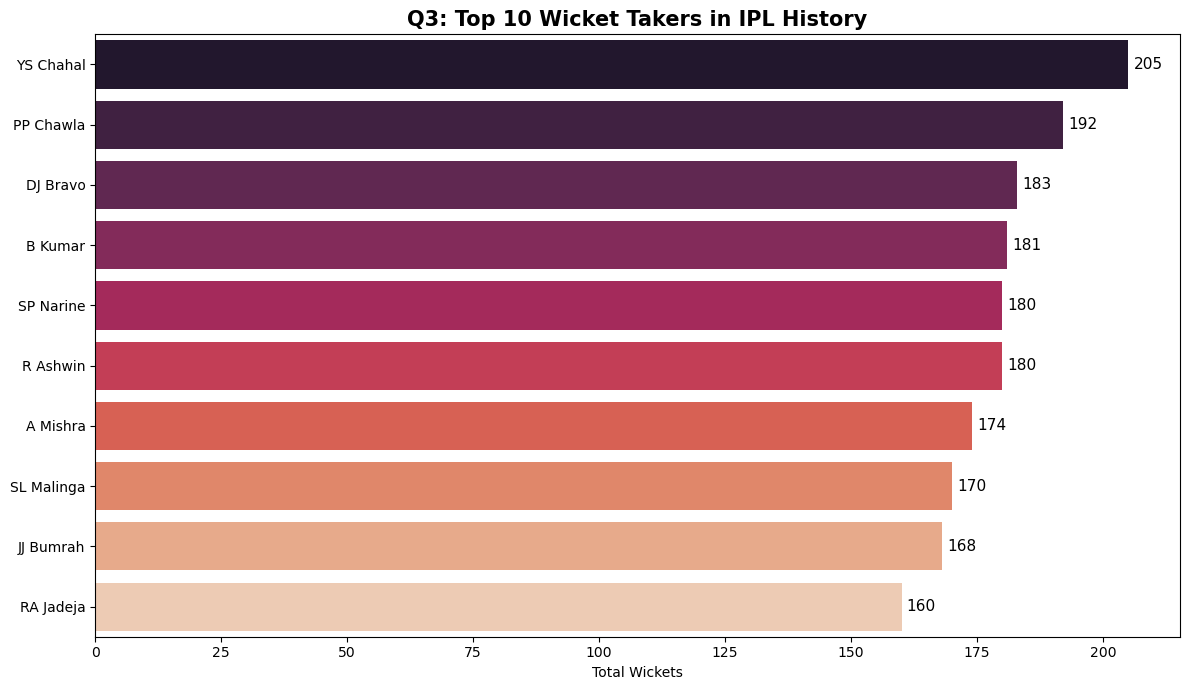

📌 YS Chahal leads with 205 wickets!


In [20]:
#Top 10 Wicket Takers in IPL History
wkts = deliveries[
    deliveries['dismissal_kind'].notna() &
    ~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field'])
]
top_bowl = (wkts.groupby('bowler')['dismissal_kind']
            .count().sort_values(ascending=False).head(10).reset_index())
top_bowl.columns = ['bowler', 'wickets']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_bowl, x='wickets', y='bowler', palette='rocket')
for i, val in enumerate(top_bowl['wickets']):
    plt.text(val+1, i, str(val), va='center', fontsize=11)
plt.title('Q3: Top 10 Wicket Takers in IPL History', fontsize=15, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('')
plt.tight_layout()
plt.show()
print(f'📌 {top_bowl.iloc[0]["bowler"]} leads with {top_bowl.iloc[0]["wickets"]} wickets!')

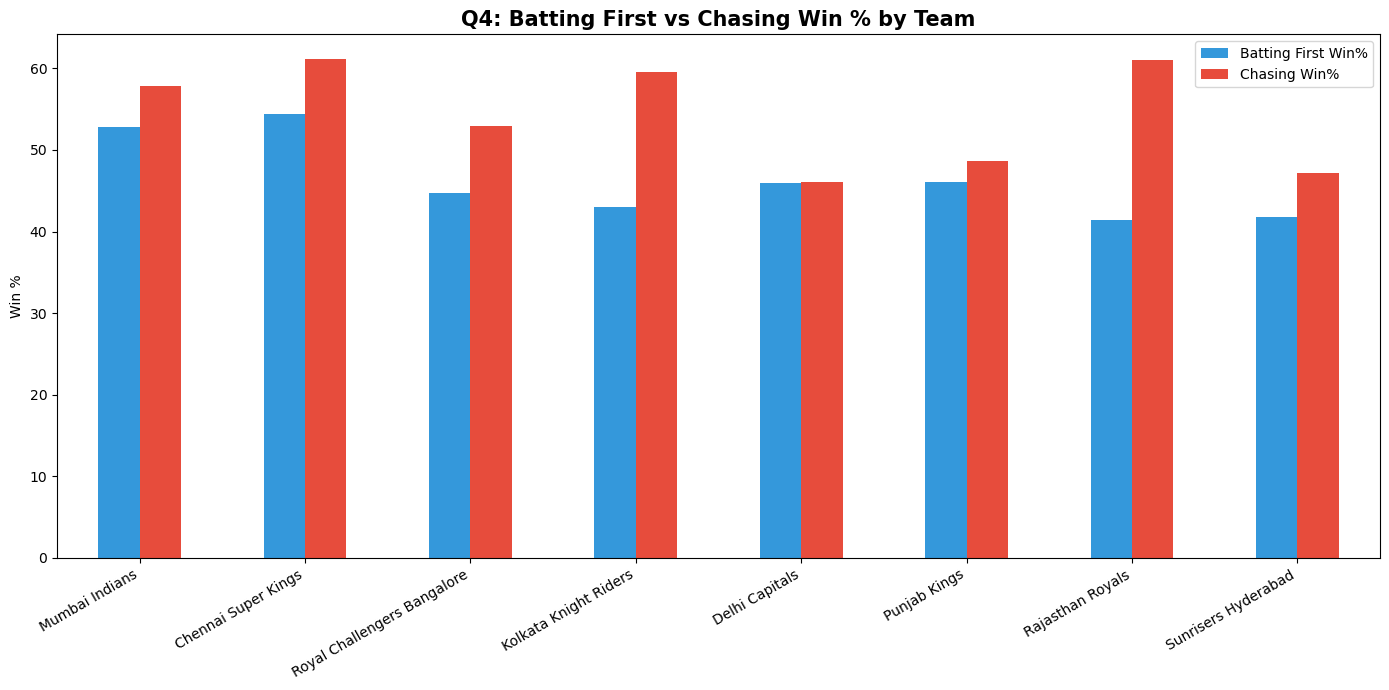

In [21]:
#Win rate: batting first vs chasing (by team)
valid = matches[matches['winner'].notna()].copy()

def get_batting_first(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    return row['team2'] if row['toss_winner'] == row['team1'] else row['team1']

valid['bat_first'] = valid.apply(get_batting_first, axis=1)
valid['chaser'] = valid.apply(
    lambda r: r['team2'] if r['bat_first'] == r['team1'] else r['team1'], axis=1)

bat_wins = valid[valid['winner']==valid['bat_first']].groupby('bat_first').size()
bat_total = valid.groupby('bat_first').size()
bat_rate = (bat_wins/bat_total*100).dropna()

chase_wins = valid[valid['winner']==valid['chaser']].groupby('chaser').size()
chase_total = valid.groupby('chaser').size()
chase_rate = (chase_wins/chase_total*100).dropna()

active_teams = ['Mumbai Indians','Chennai Super Kings','Royal Challengers Bangalore',
                'Kolkata Knight Riders','Delhi Capitals','Punjab Kings',
                'Rajasthan Royals','Sunrisers Hyderabad']

compare = pd.DataFrame({
    'Batting First Win%': bat_rate,
    'Chasing Win%': chase_rate
}).loc[[t for t in active_teams if t in bat_rate.index]].fillna(0)

compare.plot(kind='bar', figsize=(14,7), color=['#3498db','#e74c3c'])
plt.title('Q4: Batting First vs Chasing Win % by Team', fontsize=15, fontweight='bold')
plt.ylabel('Win %')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

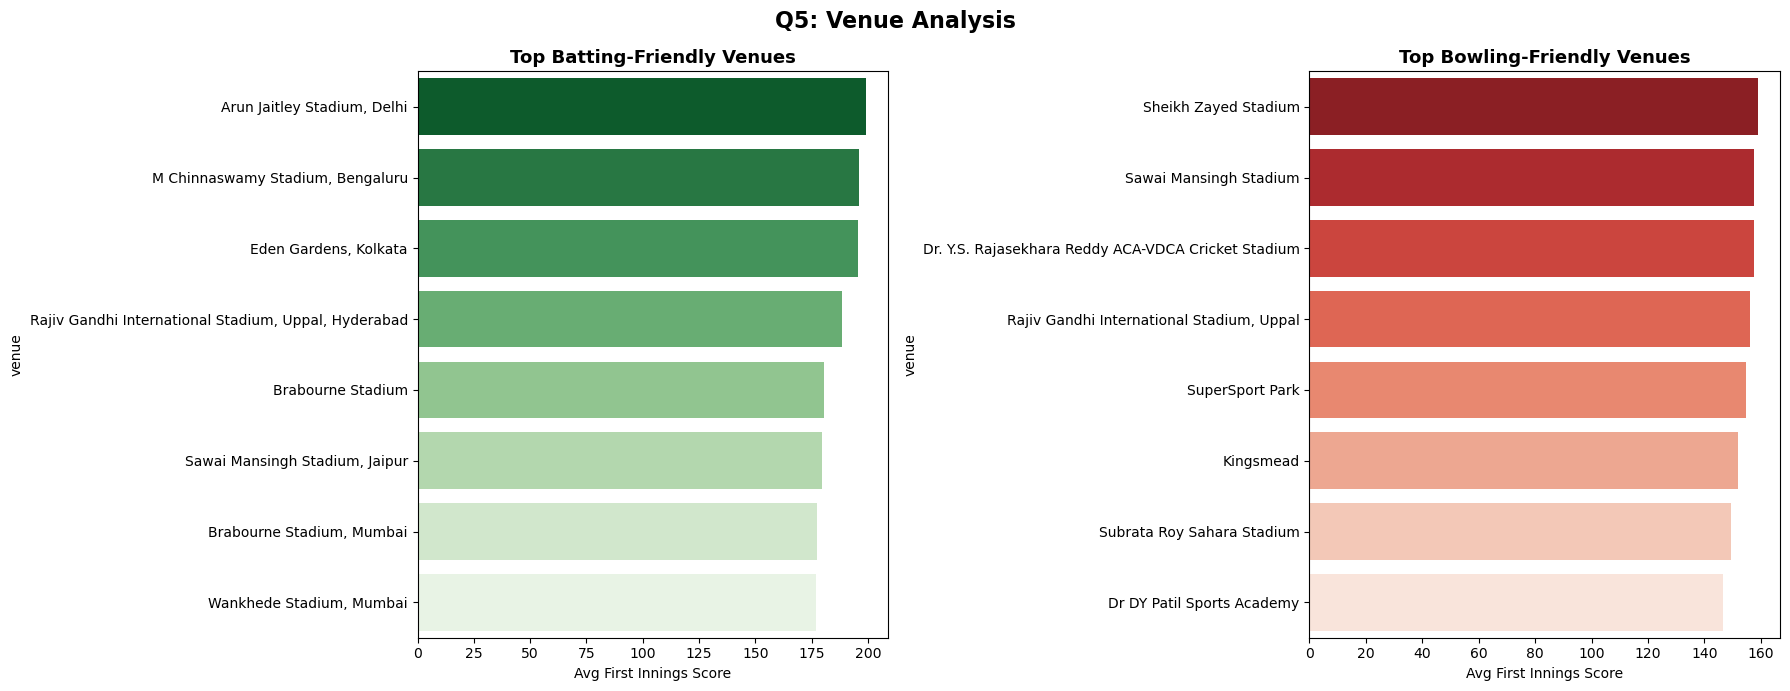

In [23]:
#
venue_scores = (deliveries[deliveries['inning']==1]
                .groupby(['venue','match_id'])['total_runs']
                .sum().reset_index()
                .groupby('venue')['total_runs']
                .agg(['mean','count']).reset_index())
venue_scores.columns = ['venue','avg_score','matches']
venue_scores = venue_scores[venue_scores['matches'] >= 10].sort_values('avg_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=venue_scores.head(8), x='avg_score', y='venue', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Batting-Friendly Venues', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg First Innings Score')

sns.barplot(data=venue_scores.tail(8), x='avg_score', y='venue', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top Bowling-Friendly Venues', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg First Innings Score')

plt.suptitle('Q5: Venue Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

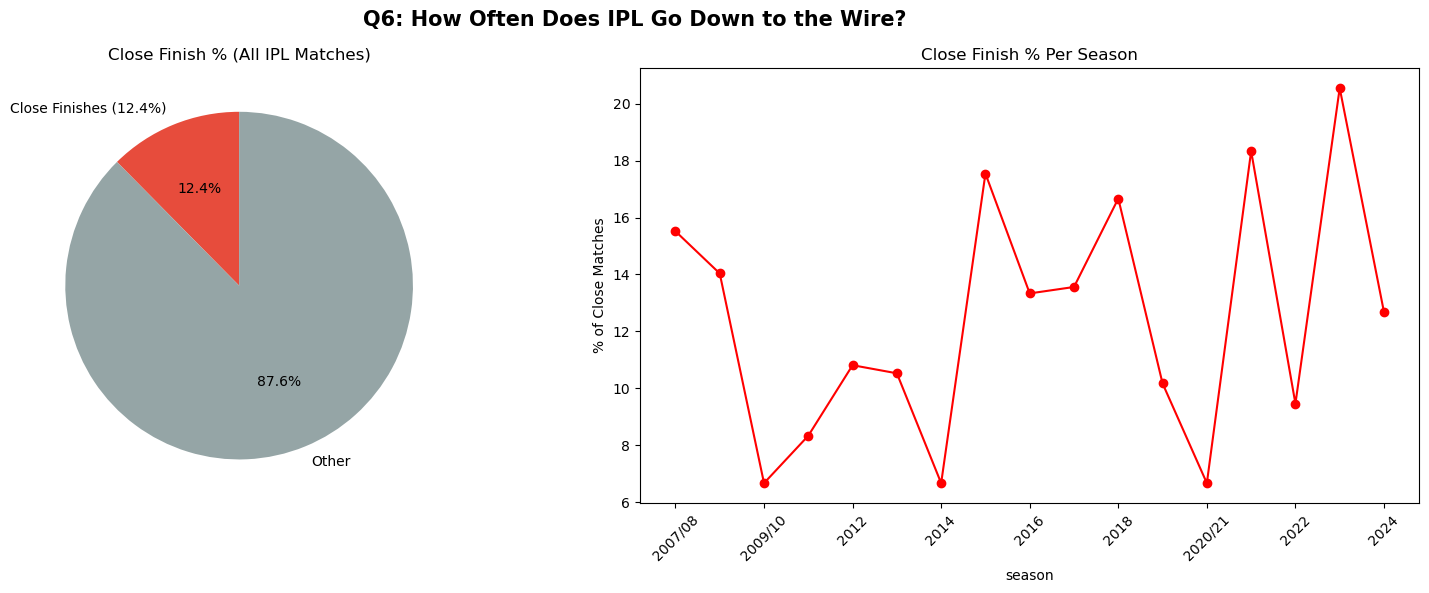

📌 12.4% of IPL matches are close finishes!


In [22]:
#
valid = matches[matches['winner'].notna()].copy()
valid['is_close'] = (
    ((valid['result'] == 'runs') & (valid['result_margin'] <= 10)) |
    ((valid['result'] == 'wickets') & (valid['result_margin'] <= 2))
)
pct = round(valid['is_close'].mean()*100, 1)
season_close = valid.groupby('season')['is_close'].mean()*100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].pie([pct, 100-pct],
            labels=[f'Close Finishes ({pct}%)', 'Other'],
            autopct='%1.1f%%', colors=['#e74c3c','#95a5a6'], startangle=90)
axes[0].set_title('Close Finish % (All IPL Matches)')

season_close.plot(kind='line', marker='o', color='red', ax=axes[1])
axes[1].set_title('Close Finish % Per Season')
axes[1].set_ylabel('% of Close Matches')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Q6: How Often Does IPL Go Down to the Wire?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'📌 {pct}% of IPL matches are close finishes!')

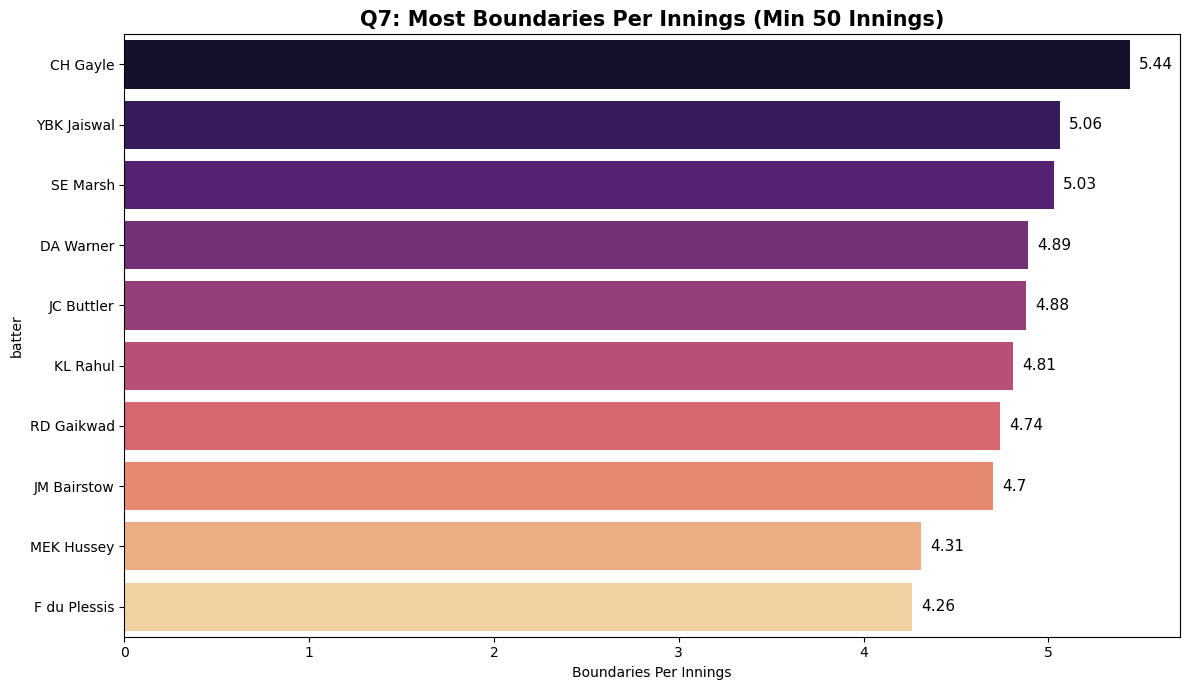

📌 CH Gayle hits 5.44 boundaries every innings!


In [24]:
#
boundaries = deliveries[deliveries['batsman_runs'].isin([4,6])]
b_count = boundaries.groupby(batter_col)['batsman_runs'].count().reset_index()
b_count.columns = ['batter','boundaries']

innings = (deliveries.groupby([batter_col,'match_id']).size()
           .reset_index().groupby(batter_col).size().reset_index())
innings.columns = ['batter','innings']

merged = b_count.merge(innings, on='batter')
merged = merged[merged['innings'] >= 50]
merged['per_innings'] = (merged['boundaries']/merged['innings']).round(2)
merged = merged.sort_values('per_innings', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=merged, x='per_innings', y='batter', palette='magma')
for i, val in enumerate(merged['per_innings']):
    plt.text(val+0.05, i, str(val), va='center', fontsize=11)
plt.title('Q7: Most Boundaries Per Innings (Min 50 Innings)', fontsize=15, fontweight='bold')
plt.xlabel('Boundaries Per Innings')
plt.tight_layout()
plt.show()
print(f'📌 {merged.iloc[0]["batter"]} hits {merged.iloc[0]["per_innings"]} boundaries every innings!')

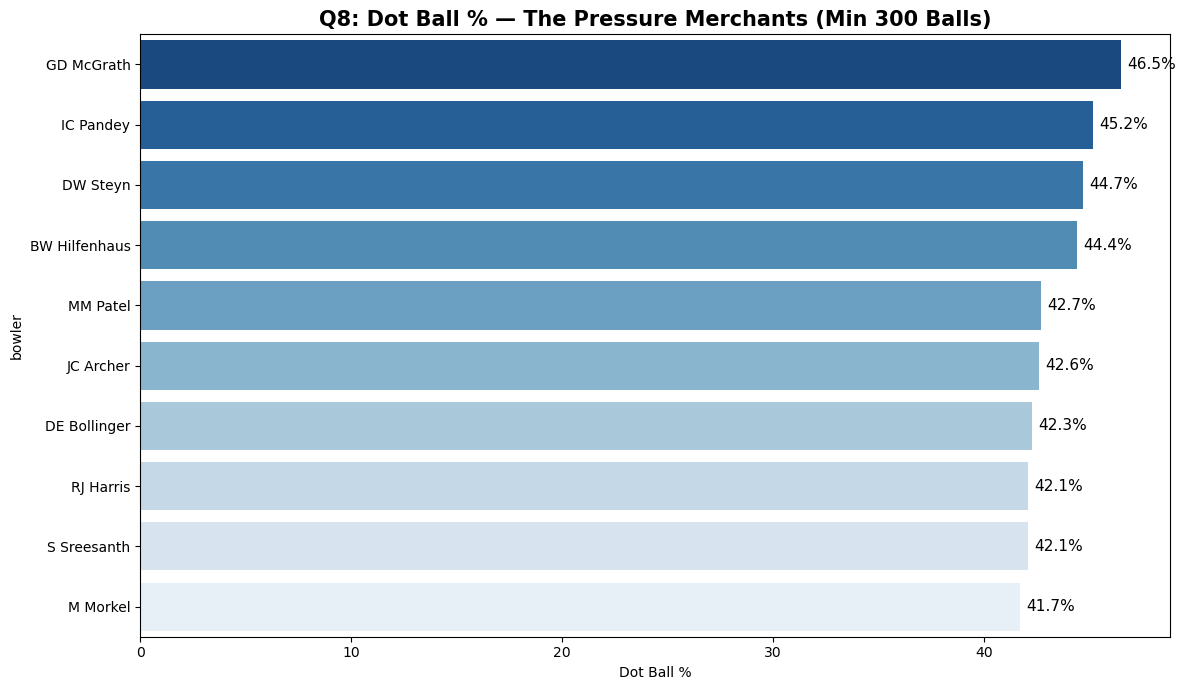

📌 GD McGrath bowls a dot 46.5% of the time!


In [25]:
deliveries['is_dot'] = (deliveries['total_runs'] == 0).astype(int)
dot = deliveries.groupby('bowler').agg(
    balls=('total_runs','count'),
    dots=('is_dot','sum')
).reset_index()
dot = dot[dot['balls'] >= 300]
dot['dot_pct'] = (dot['dots']/dot['balls']*100).round(1)
dot = dot.sort_values('dot_pct', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=dot, x='dot_pct', y='bowler', palette='Blues_r')
for i, val in enumerate(dot['dot_pct']):
    plt.text(val+0.3, i, f'{val}%', va='center', fontsize=11)
plt.title('Q8: Dot Ball % — The Pressure Merchants (Min 300 Balls)', fontsize=15, fontweight='bold')
plt.xlabel('Dot Ball %')
plt.tight_layout()
plt.show()
print(f'📌 {dot.iloc[0]["bowler"]} bowls a dot {dot.iloc[0]["dot_pct"]}% of the time!')



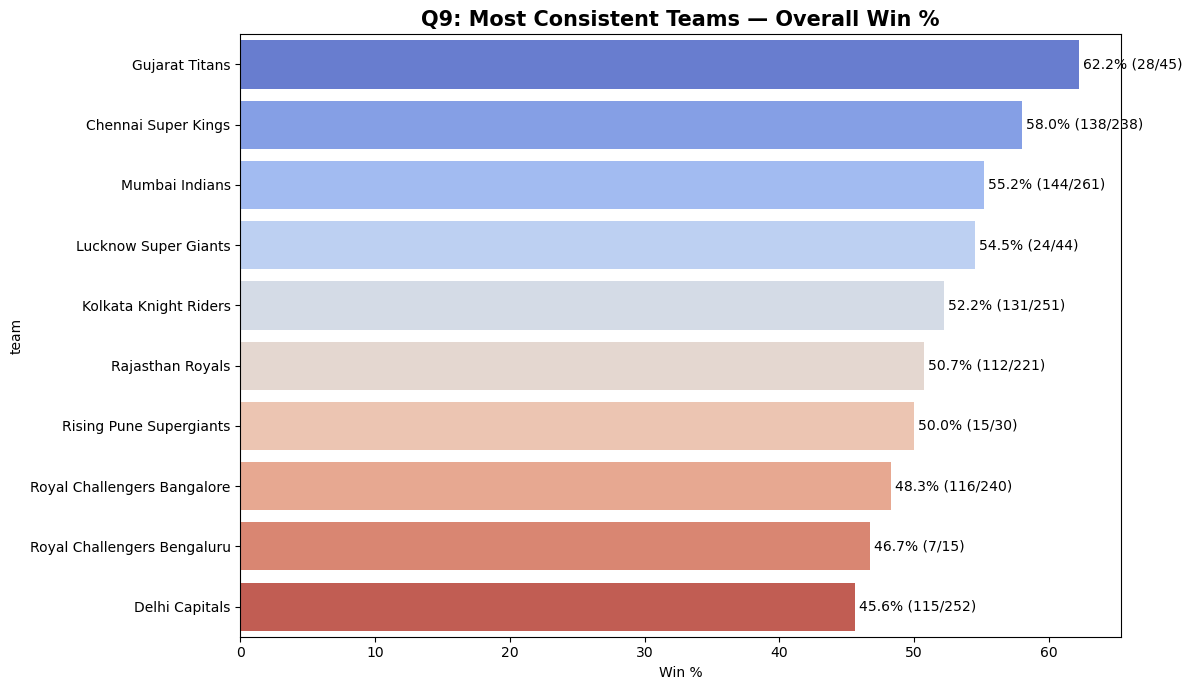

In [26]:
#
wins = matches[matches['winner'].notna()]['winner'].value_counts().reset_index()
wins.columns = ['team','wins']

t1 = matches['team1'].value_counts()
t2 = matches['team2'].value_counts()
total_played = t1.add(t2, fill_value=0).reset_index()
total_played.columns = ['team','played']

merged = wins.merge(total_played, on='team')
merged['win_pct'] = (merged['wins']/merged['played']*100).round(1)
merged = merged.sort_values('win_pct', ascending=False).head(10)

plt.figure(figsize=(12, 7))
bars = sns.barplot(data=merged, x='win_pct', y='team', palette='coolwarm')
for i, (val, w, p) in enumerate(zip(merged['win_pct'], merged['wins'], merged['played'])):
    plt.text(val+0.3, i, f'{val}% ({w}/{p})', va='center', fontsize=10)
plt.title('Q9: Most Consistent Teams — Overall Win %', fontsize=15, fontweight='bold')
plt.xlabel('Win %')
plt.tight_layout()
plt.show()

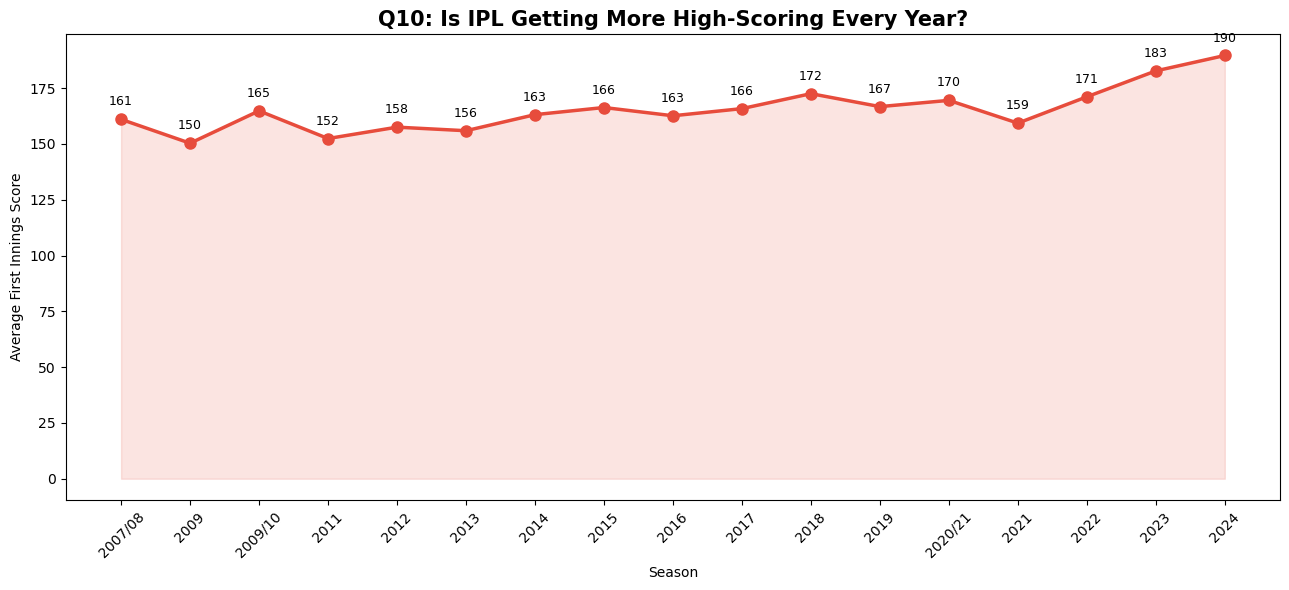

📌 2007/08: 161.0 → 2024: 189.6 — that's the T20 evolution!


In [27]:
#How has avg first innings score changed over seasons?
season_avg = (deliveries[deliveries['inning']==1]
              .groupby(['season','match_id'])['total_runs']
              .sum().groupby('season').mean().round(1).reset_index())
season_avg.columns = ['season','avg_score']

plt.figure(figsize=(13, 6))
plt.plot(season_avg['season'].astype(str), season_avg['avg_score'],
         marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
for _, row in season_avg.iterrows():
    plt.annotate(f"{row['avg_score']:.0f}",
                 (str(row['season']), row['avg_score']),
                 textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
plt.fill_between(season_avg['season'].astype(str), season_avg['avg_score'], alpha=0.15, color='#e74c3c')
plt.title('Q10: Is IPL Getting More High-Scoring Every Year?', fontsize=15, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average First Innings Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"📌 {season_avg.iloc[0]['season']}: {season_avg.iloc[0]['avg_score']} → {season_avg.iloc[-1]['season']}: {season_avg.iloc[-1]['avg_score']} — that's the T20 evolution!")


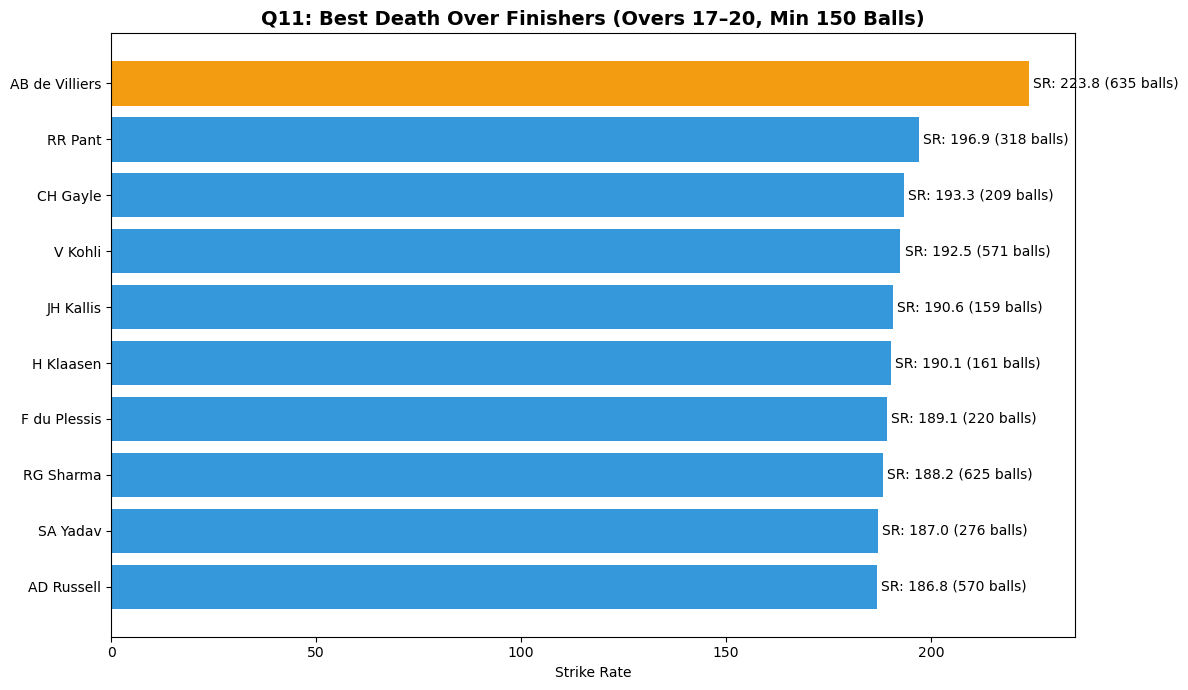

📌 AB de Villiers is the most destructive finisher with SR of 223.8!


In [28]:
#Best death over batsmen (SR in overs 17–20)
death_bat = deliveries[deliveries['over'] >= 16]
sr = death_bat.groupby(batter_col).agg(
    runs=('batsman_runs','sum'),
    balls=('batsman_runs','count')
).reset_index()
sr = sr[sr['balls'] >= 150]
sr['strike_rate'] = (sr['runs']/sr['balls']*100).round(1)
sr = sr.sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(12, 7))
colors = ['#f39c12' if i==0 else '#3498db' for i in range(len(sr))]
plt.barh(sr[batter_col], sr['strike_rate'], color=colors)
for i, (val, balls) in enumerate(zip(sr['strike_rate'], sr['balls'])):
    plt.text(val+1, i, f'SR: {val} ({balls} balls)', va='center', fontsize=10)
plt.title('Q11: Best Death Over Finishers (Overs 17–20, Min 150 Balls)', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(f'📌 {sr.iloc[0][batter_col]} is the most destructive finisher with SR of {sr.iloc[0]["strike_rate"]}!')

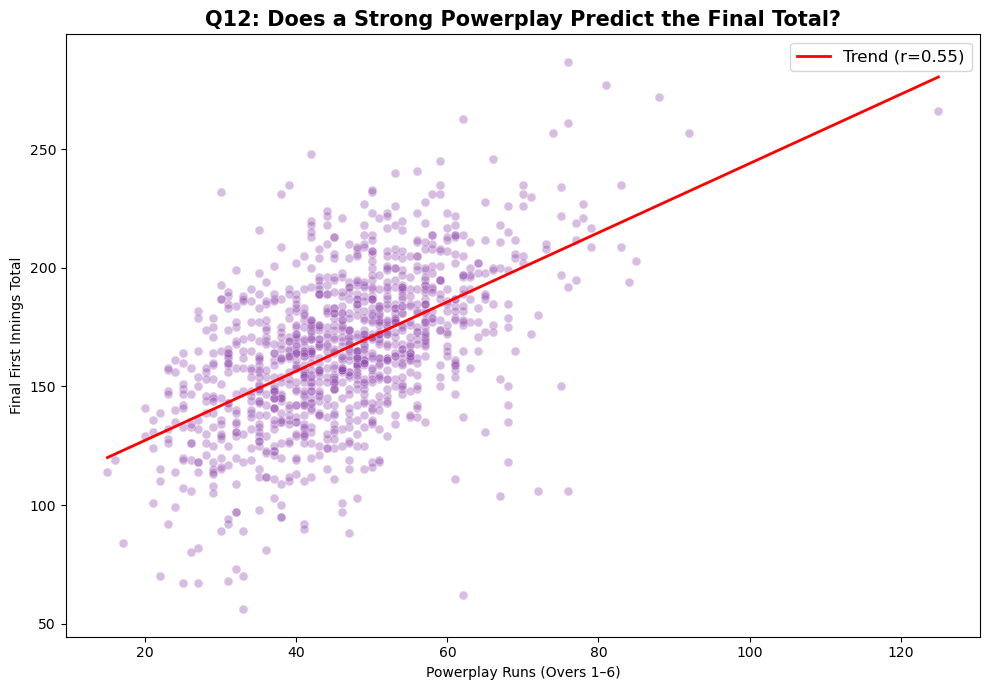

📌 Correlation = 0.55 — powerplay score has a moderate link with final total!


In [29]:
#Does powerplay score predict final total? (Correlation)

pp = (deliveries[(deliveries['inning']==1) & (deliveries['over']<6)]
      .groupby('match_id')['total_runs'].sum().reset_index())
pp.columns = ['match_id','pp_runs']

total = (deliveries[deliveries['inning']==1]
         .groupby('match_id')['total_runs'].sum().reset_index())
total.columns = ['match_id','final_total']

merged = pp.merge(total, on='match_id')
corr = merged['pp_runs'].corr(merged['final_total'])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=merged, x='pp_runs', y='final_total', alpha=0.35, color='#8e44ad', s=40)
z = np.polyfit(merged['pp_runs'], merged['final_total'], 1)
x_line = np.linspace(merged['pp_runs'].min(), merged['pp_runs'].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, label=f'Trend (r={corr:.2f})')
plt.title('Q12: Does a Strong Powerplay Predict the Final Total?', fontsize=15, fontweight='bold')
plt.xlabel('Powerplay Runs (Overs 1–6)')
plt.ylabel('Final First Innings Total')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print(f'📌 Correlation = {corr:.2f} — powerplay score has a {"strong" if corr > 0.6 else "moderate"} link with final total!')

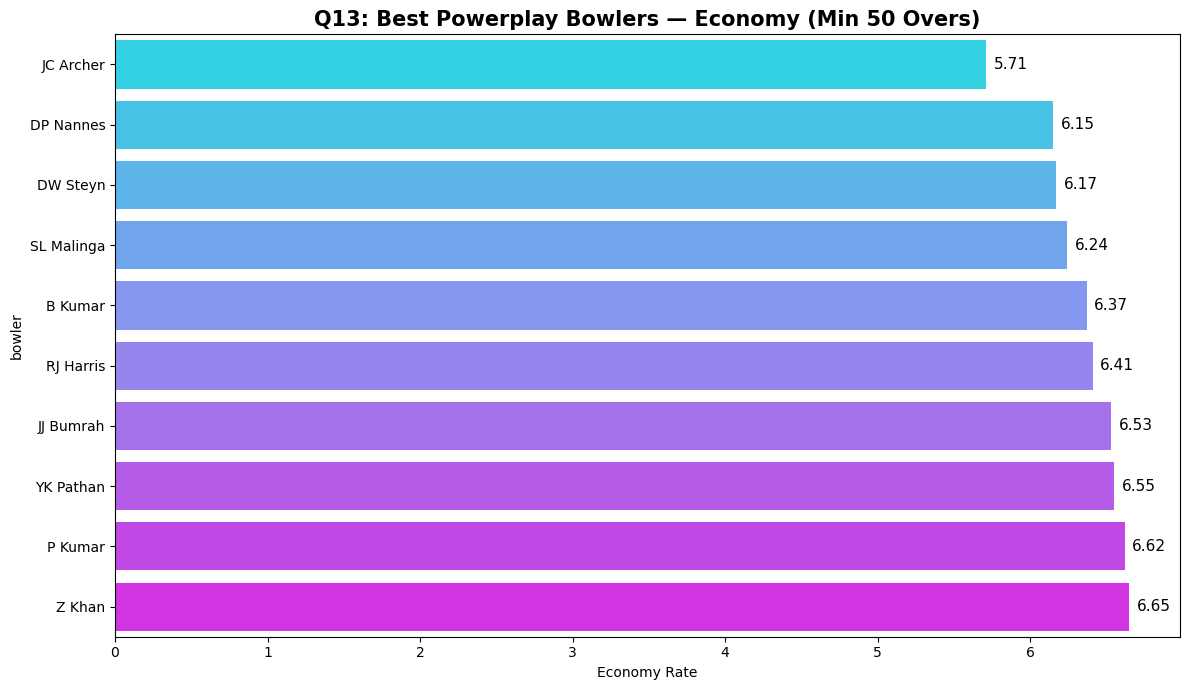

📌 JC Archer is the most economical powerplay bowler!


In [30]:
#Best powerplay bowlers (economy, overs 1–6)
pp_bowl = deliveries[deliveries['over'] < 6]
pp_econ = pp_bowl.groupby('bowler').agg(
    runs=('total_runs','sum'),
    balls=('total_runs','count')
).reset_index()
pp_econ['overs'] = pp_econ['balls']/6
pp_econ = pp_econ[pp_econ['overs'] >= 50]
pp_econ['economy'] = (pp_econ['runs']/pp_econ['overs']).round(2)
pp_econ = pp_econ.sort_values('economy').head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=pp_econ, x='economy', y='bowler', palette='cool')
for i, val in enumerate(pp_econ['economy']):
    plt.text(val+0.05, i, str(val), va='center', fontsize=11)
plt.title('Q13: Best Powerplay Bowlers — Economy (Min 50 Overs)', fontsize=15, fontweight='bold')
plt.xlabel('Economy Rate')
plt.tight_layout()
plt.show()
print(f'📌 {pp_econ.iloc[0]["bowler"]} is the most economical powerplay bowler!')

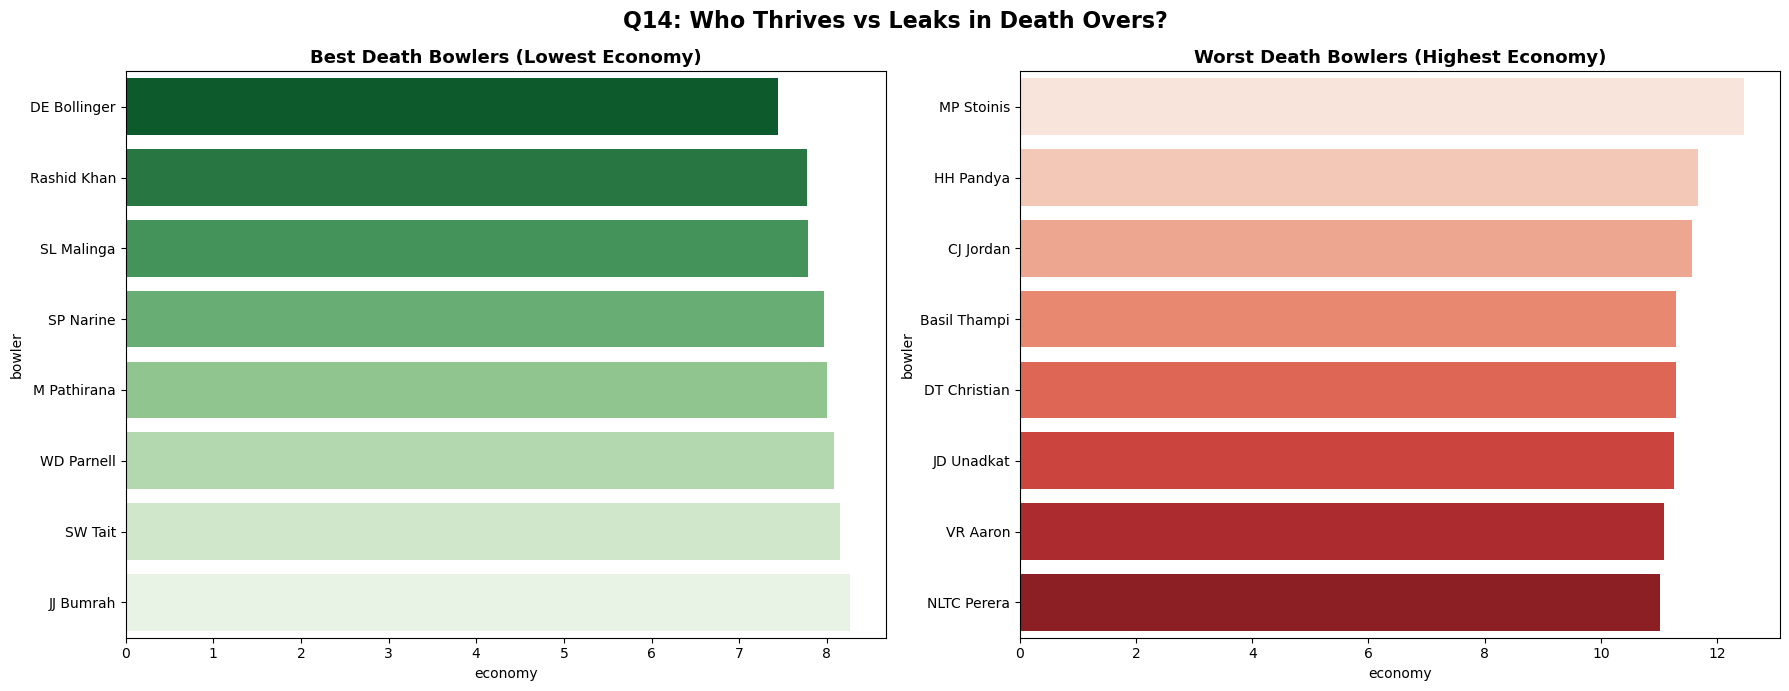

In [31]:
#Who leaks most in death overs? Best vs worst
death = deliveries[deliveries['over'] >= 16]
de = death.groupby('bowler').agg(
    runs=('total_runs','sum'),
    balls=('total_runs','count')
).reset_index()
de['overs'] = de['balls']/6
de = de[de['overs'] >= 20]
de['economy'] = (de['runs']/de['overs']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
best = de.sort_values('economy').head(8)
sns.barplot(data=best, x='economy', y='bowler', ax=axes[0], palette='Greens_r')
axes[0].set_title('Best Death Bowlers (Lowest Economy)', fontsize=13, fontweight='bold')

worst = de.sort_values('economy', ascending=False).head(8)
sns.barplot(data=worst, x='economy', y='bowler', ax=axes[1], palette='Reds')
axes[1].set_title('Worst Death Bowlers (Highest Economy)', fontsize=13, fontweight='bold')

plt.suptitle('Q14: Who Thrives vs Leaks in Death Overs?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

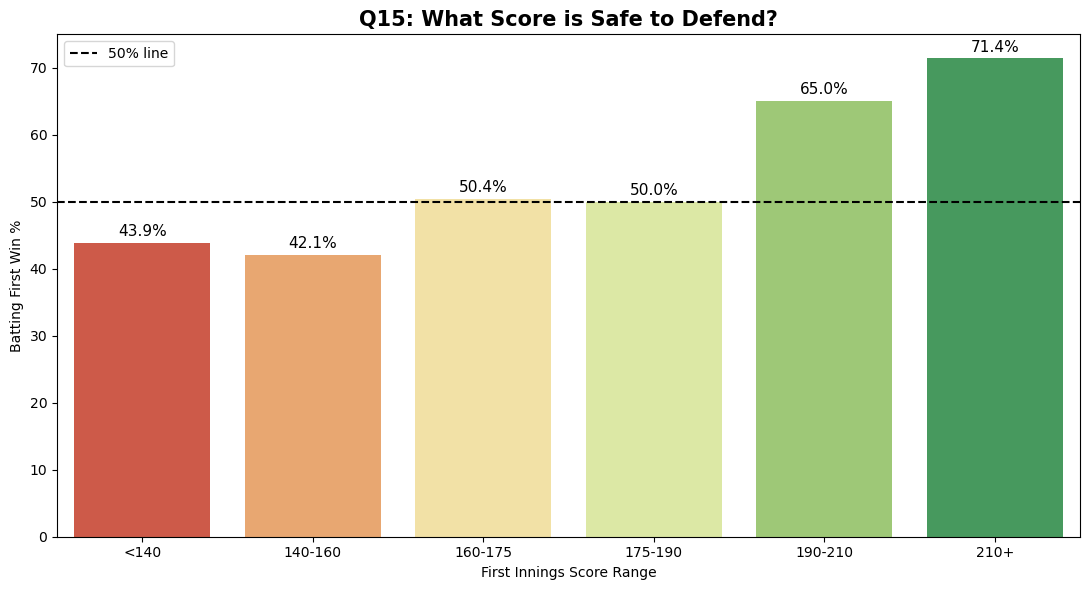

📌 Crossing 175 runs is the tipping point — win rate jumps significantly!


In [32]:
#What score is safe to defend?
first_inn = (deliveries[deliveries['inning']==1]
             .groupby('match_id')['total_runs'].sum().reset_index())
first_inn.columns = ['id','first_score']
first_inn['id'] = first_inn['id'].astype(str)

merged = matches[['id','team1','team2','winner']].merge(first_inn, on='id')
merged['bat_first_won'] = (merged['winner'] == merged['team1']).astype(int)
merged['score_bucket'] = pd.cut(merged['first_score'],
    bins=[0,140,160,175,190,210,300],
    labels=['<140','140-160','160-175','175-190','190-210','210+'])

win_by_score = merged.groupby('score_bucket')['bat_first_won'].mean().reset_index()
win_by_score['win_pct'] = (win_by_score['bat_first_won']*100).round(1)

plt.figure(figsize=(11, 6))
bars = sns.barplot(data=win_by_score, x='score_bucket', y='win_pct', palette='RdYlGn')
plt.axhline(50, color='black', linestyle='--', linewidth=1.5, label='50% line')
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x()+p.get_width()/2, p.get_height()+1), ha='center', fontsize=11)
plt.title('Q15: What Score is Safe to Defend?', fontsize=15, fontweight='bold')
plt.xlabel('First Innings Score Range')
plt.ylabel('Batting First Win %')
plt.legend()
plt.tight_layout()
plt.show()
print('📌 Crossing 175 runs is the tipping point — win rate jumps significantly!')

extra_runs
Using column: extra_runs


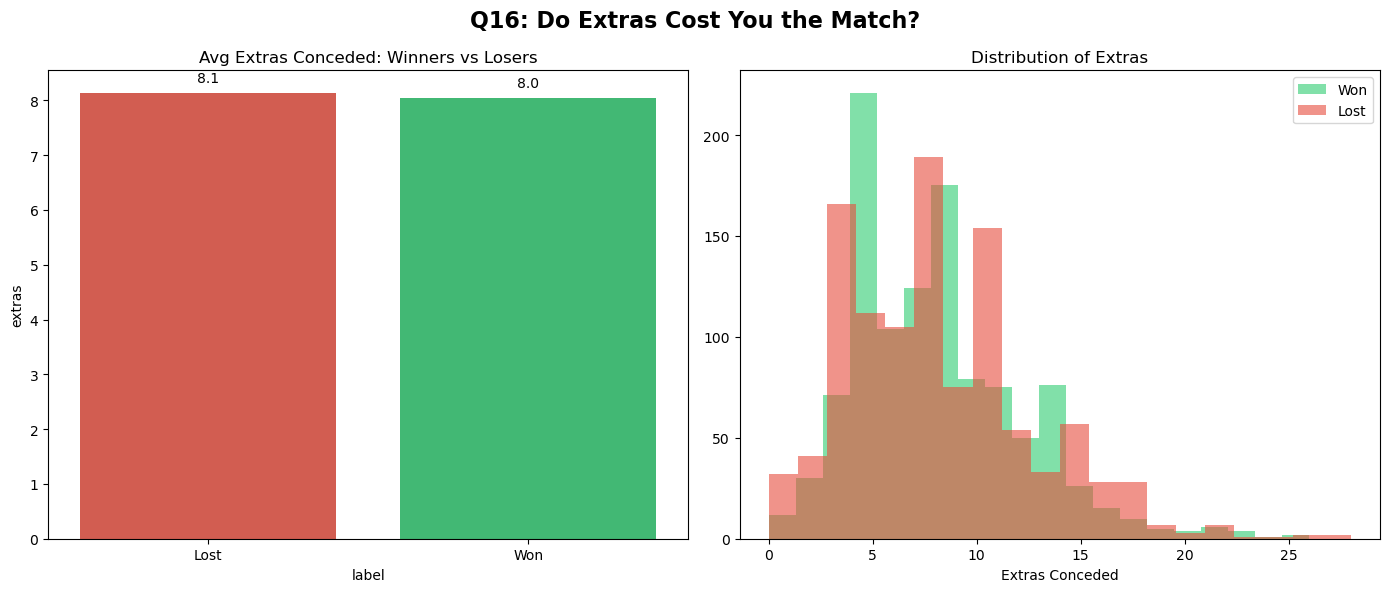

📌 Losing teams concede 8.1 extras vs 8.0 for winners!


In [34]:
#Do extras cost you the match?
# Check actual column name
extra_col = None
for col in deliveries.columns:
    if 'extra' in col.lower():
        print(col)
        extra_col = col
        break

print('Using column:', extra_col)

# Extras per match per bowling team
extras_match = (deliveries.groupby(['match_id', 'bowling_team'])[extra_col]
                .sum().reset_index())
extras_match.columns = ['id', 'team', 'extras']
extras_match['id'] = extras_match['id'].astype(str)

merged = extras_match.merge(matches[['id', 'winner']], on='id')
merged['team_won'] = (merged['team'] == merged['winner']).astype(int)

result = merged.groupby('team_won')['extras'].mean().reset_index()
result['label'] = result['team_won'].map({0: 'Lost', 1: 'Won'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=result, x='label', y='extras', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Avg Extras Conceded: Winners vs Losers')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center')

won = merged[merged['team_won'] == 1]['extras']
lost = merged[merged['team_won'] == 0]['extras']
axes[1].hist(won, bins=20, alpha=0.6, color='#2ecc71', label='Won')
axes[1].hist(lost, bins=20, alpha=0.6, color='#e74c3c', label='Lost')
axes[1].set_title('Distribution of Extras')
axes[1].set_xlabel('Extras Conceded')
axes[1].legend()

plt.suptitle('Q16: Do Extras Cost You the Match?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'📌 Losing teams concede {result[result["team_won"]==0]["extras"].values[0]:.1f} extras vs {result[result["team_won"]==1]["extras"].values[0]:.1f} for winners!')

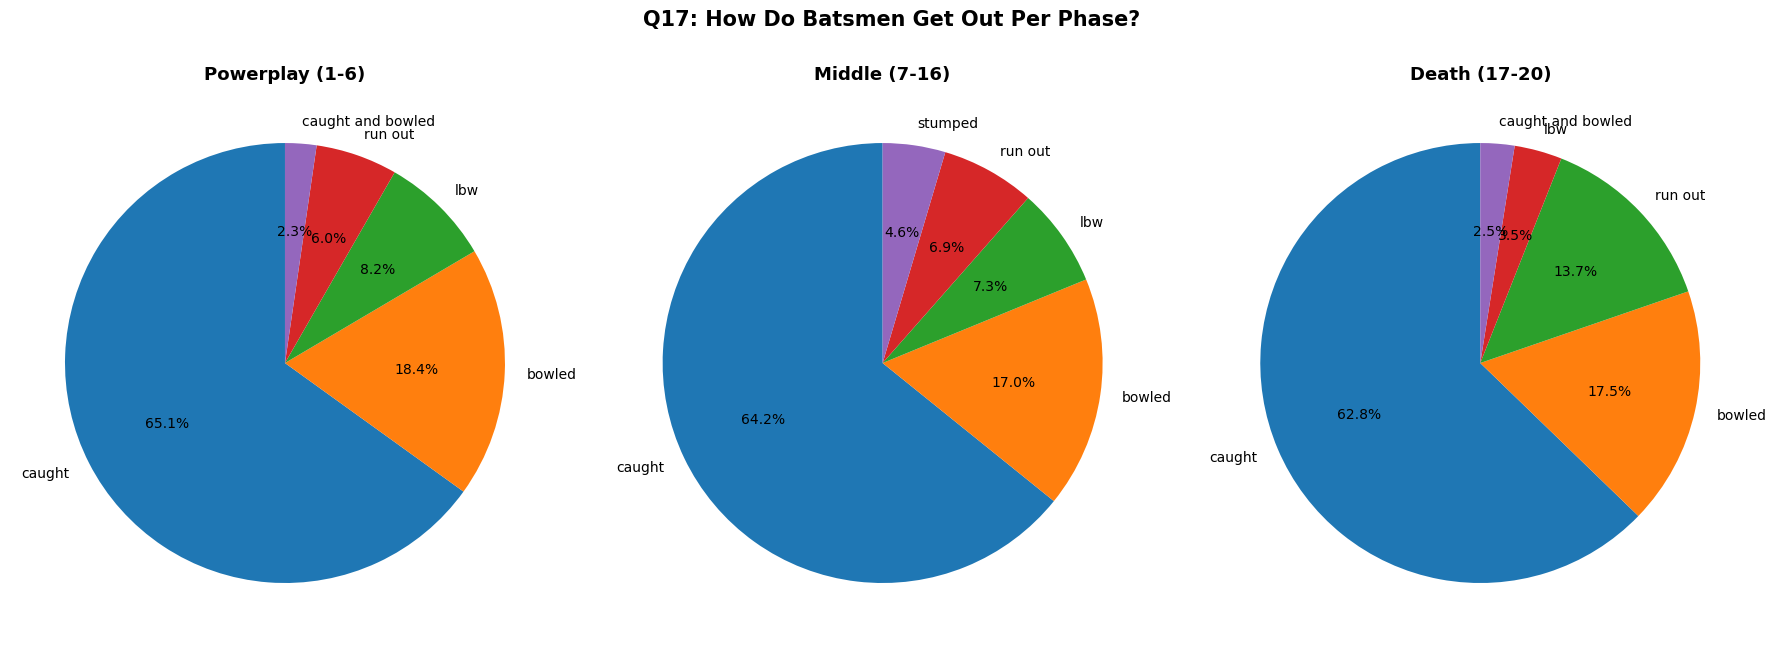

📌 Caught dominates all phases — but watch how bowled/lbw changes across powerplay vs death!


In [35]:
#Which dismissal type is most common per phase?

dismissed = deliveries[deliveries['dismissal_kind'].notna()].copy()

def phase(over):
    if over < 6: return 'Powerplay (1-6)'
    elif over < 16: return 'Middle (7-16)'
    else: return 'Death (17-20)'

dismissed['phase'] = dismissed['over'].apply(phase)

phases = ['Powerplay (1-6)', 'Middle (7-16)', 'Death (17-20)']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, p in zip(axes, phases):
    data = (dismissed[dismissed['phase']==p]
            .groupby('dismissal_kind').size()
            .sort_values(ascending=False).head(5).reset_index())
    data.columns = ['kind','count']
    total = data['count'].sum()
    data['pct'] = (data['count']/total*100).round(1)
    ax.pie(data['pct'], labels=data['kind'], autopct='%1.1f%%', startangle=90)
    ax.set_title(p, fontsize=13, fontweight='bold')

plt.suptitle('Q17: How Do Batsmen Get Out Per Phase?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Caught dominates all phases — but watch how bowled/lbw changes across powerplay vs death!')